In [5]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 15
NUM_CLASSES = 5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [7]:
PROJECT_ROOT = Path.cwd().parents[1]

DATASET_DIR = PROJECT_ROOT / "ml" / "data" / "raw" / "mendeley"

SPLIT_DIR = PROJECT_ROOT / "ml" / "data" / "splits" / "mendeley"

MODEL_DIR = PROJECT_ROOT / "ml" / "models" / "mendeley"

RESULT_DIR = PROJECT_ROOT / "ml" / "results" / "mendeley"

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULT_DIR)

Dataset: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/data/raw/mendeley
Models: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley
Results: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/results/mendeley


In [8]:
# 1. Discover images
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
records = []
for image_path in DATASET_DIR.rglob('*'):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        records.append({'image_path': str(image_path.resolve()), 'label': image_path.parent.name})

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError(f'No images found in {DATASET_DIR}')

print('\nTotal images:', len(df))
print(df['label'].value_counts().sort_index())
df.to_csv(SPLIT_DIR / 'all_images.csv', index=False)


Total images: 5798
label
Bud Root Dropping     514
Bud Rot               470
Gray Leaf Spot       2135
Leaf Rot             1673
Stem Bleeding        1006
Name: count, dtype: int64


In [9]:
# 2. Class mapping
class_names = sorted(df['label'].unique())
if len(class_names) != NUM_CLASSES:
    raise ValueError(f'Expected {NUM_CLASSES} classes, found {len(class_names)}: {class_names}')
CLASS_TO_INDEX = {name: i for i, name in enumerate(class_names)}
INDEX_TO_CLASS = {i: name for name, i in CLASS_TO_INDEX.items()}
print('\nClass mapping:')
for i, name in INDEX_TO_CLASS.items():
    print(i, '->', name)



Class mapping:
0 -> Bud Root Dropping
1 -> Bud Rot
2 -> Gray Leaf Spot
3 -> Leaf Rot
4 -> Stem Bleeding


In [10]:
# 3. Stratified 70/15/15 split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print('\nDataset split:')
print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

train_df.to_csv(SPLIT_DIR / 'train.csv', index=False)
val_df.to_csv(SPLIT_DIR / 'val.csv', index=False)
test_df.to_csv(SPLIT_DIR / 'test.csv', index=False)


Dataset split:
Train: 4058
Validation: 870
Test: 870


In [11]:
# 4. TensorFlow input pipeline
AUTOTUNE = tf.data.AUTOTUNE

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def dataframe_to_dataset(dataframe, shuffle=False):
    paths = dataframe['image_path'].values
    labels = dataframe['label'].map(CLASS_TO_INDEX).values
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = dataframe_to_dataset(train_df, shuffle=True)
val_ds = dataframe_to_dataset(val_df)
test_ds = dataframe_to_dataset(test_df)

In [12]:
# 5. Augmentation
# MobileNetV3Small with include_preprocessing=True handles its own input scaling.
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

In [13]:
# 6. Class weights
train_class_indices = np.array([CLASS_TO_INDEX[label] for label in train_df['label']])
classes = np.unique(train_class_indices)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_class_indices)
class_weights = {int(i): float(w) for i, w in zip(classes, weights)}
print('\nClass weights:')
for i, w in class_weights.items():
    print(f'{INDEX_TO_CLASS[i]}: {w:.4f}')


Class weights:
Bud Root Dropping: 2.2544
Bud Rot: 2.4669
Gray Leaf Spot: 0.5432
Leaf Rot: 0.6931
Stem Bleeding: 1.1528


In [14]:
# 7. MobileNetV3Small transfer-learning model
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name='image')
x = data_augmentation(inputs, training=True)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
model = keras.Model(inputs, outputs, name='cococare_mendeley_mobilenetv3')

In [15]:
# 8. Stage 1 training
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

stage1_checkpoint = MODEL_DIR / 'mendeley_stage1_best.keras'
stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(stage1_checkpoint, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1),
]

print('\n' + '=' * 60)
print('STAGE 1 TRAINING')
print('=' * 60)
history_stage1 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
    class_weight=class_weights, callbacks=stage1_callbacks,
)


STAGE 1 TRAINING
Epoch 1/10


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.6703 - loss: 0.8424
Epoch 1: val_loss improved from None to 0.28278, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage1_best.keras

Epoch 1: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage1_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 69s 479ms/step - accuracy: 0.6703 - loss: 0.8424 - val_accuracy: 0.9276 - val_loss: 0.2828 - learning_rate: 0.0010
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8992 - loss: 0.2585
Epoch 2: val_loss improved from 0.28278 to 0.16654, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage1_best.keras

Epoch 2: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage1_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 54s 380ms/step - accuracy: 0.8992 - loss: 0.2585 - val_


STAGE 1 TEST EVALUATION
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 297ms/step - accuracy: 0.9759 - loss: 0.0649

Stage 1 Test Loss: 0.0649
Stage 1 Test Accuracy: 0.9759

Stage 1 Classification Report:
                   precision    recall  f1-score   support

Bud Root Dropping     1.0000    1.0000    1.0000        77
          Bud Rot     1.0000    0.9577    0.9784        71
   Gray Leaf Spot     0.9544    0.9812    0.9676       320
         Leaf Rot     0.9755    0.9522    0.9637       251
    Stem Bleeding     1.0000    1.0000    1.0000       151

         accuracy                         0.9759       870
        macro avg     0.9860    0.9782    0.9820       870
     weighted avg     0.9762    0.9759    0.9759       870



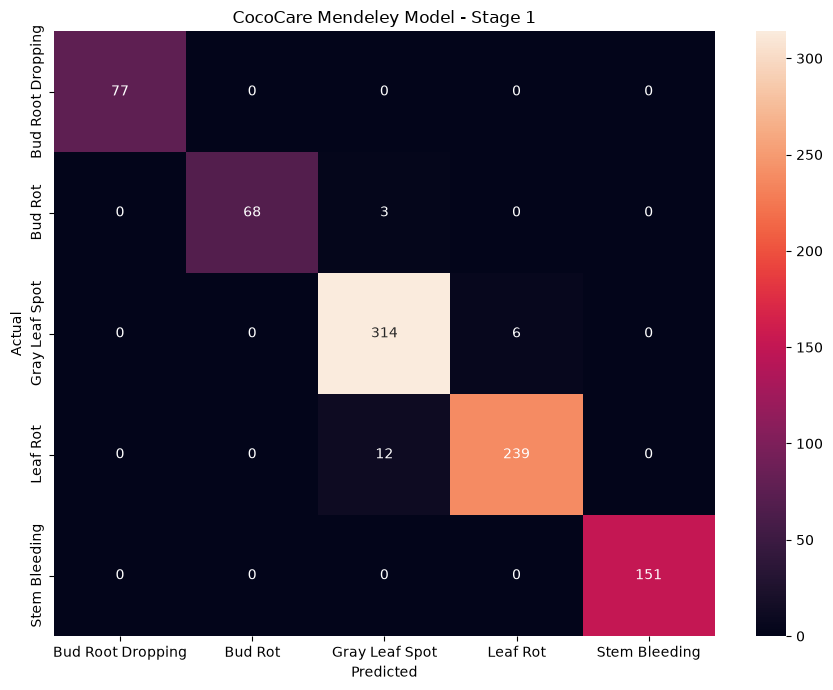

In [16]:
# 9. Evaluation helpers

def get_predictions(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        probabilities = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(probabilities, axis=1))
    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, stage_name):
    loss, accuracy = model.evaluate(test_ds, verbose=1)
    y_true, y_pred = get_predictions(model, test_ds)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n{stage_name} Test Loss: {loss:.4f}')
    print(f'{stage_name} Test Accuracy: {accuracy:.4f}')
    print(f'\n{stage_name} Classification Report:\n{report}')

    with open(RESULT_DIR / f'{stage_name.lower().replace(" ", "_")}_classification_report.txt', 'w') as f:
        f.write(report)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'CocoCare Mendeley Model - {stage_name}')
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'{stage_name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=300)
    plt.show()
    return loss, accuracy

print('\n' + '=' * 60)
print('STAGE 1 TEST EVALUATION')
print('=' * 60)
stage1_test_loss, stage1_test_accuracy = evaluate_model(model, 'Stage 1')


STAGE 2 FINE-TUNING
Total base model layers: 157
Trainable base model layers: 24
Epoch 1/15


/home/sivabharathi/miniconda3/envs/mldlenv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9717 - loss: 0.0625
Epoch 1: val_loss improved from None to 0.05678, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage2_best.keras

Epoch 1: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage2_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 81s 542ms/step - accuracy: 0.9717 - loss: 0.0625 - val_accuracy: 0.9816 - val_loss: 0.0568 - learning_rate: 1.0000e-05
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9744 - loss: 0.0578
Epoch 2: val_loss improved from 0.05678 to 0.04849, saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage2_best.keras

Epoch 2: finished saving model to /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_stage2_best.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 64s 466ms/step - accuracy: 0.9744 - loss: 0.0578 - 

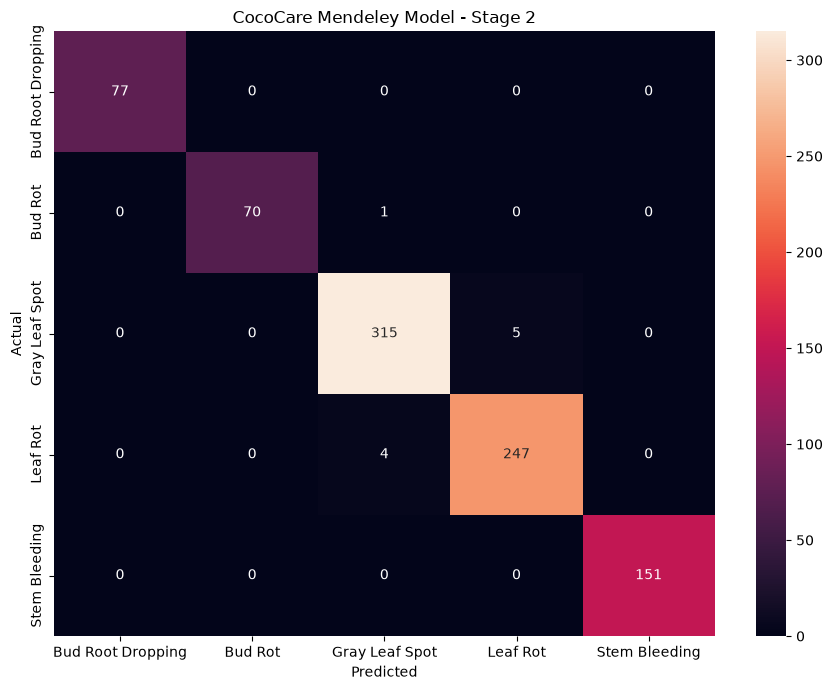

In [17]:
# 10. Stage 2 fine-tuning
print('\n' + '=' * 60)
print('STAGE 2 FINE-TUNING')
print('=' * 60)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
# Keep BatchNorm frozen during fine-tuning for stability.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print('Total base model layers:', len(base_model.layers))
print('Trainable base model layers:', sum(layer.trainable for layer in base_model.layers))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

stage2_checkpoint = MODEL_DIR / 'mendeley_stage2_best.keras'
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(stage2_checkpoint, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7, verbose=1),
]

history_stage2 = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS_FINE,
    class_weight=class_weights, callbacks=stage2_callbacks,
)

print('\n' + '=' * 60)
print('STAGE 2 TEST EVALUATION')
print('=' * 60)
stage2_test_loss, stage2_test_accuracy = evaluate_model(model, 'Stage 2')

In [18]:
# 11. Compare Stage 1 and Stage 2
comparison = pd.DataFrame({
    'Model': ['Stage 1', 'Stage 2'],
    'Test Loss': [stage1_test_loss, stage2_test_loss],
    'Test Accuracy': [stage1_test_accuracy, stage2_test_accuracy],
})
print('\n' + '=' * 60)
print('MODEL COMPARISON')
print('=' * 60)
print(comparison)
comparison.to_csv(RESULT_DIR / 'stage_comparison.csv', index=False)

# 12. Select the better model using untouched test accuracy.
if stage2_test_accuracy >= stage1_test_accuracy:
    best_model = model
    selected_stage = 'Stage 2'
else:
    best_model = keras.models.load_model(stage1_checkpoint)
    selected_stage = 'Stage 1'

final_model_path = MODEL_DIR / 'mendeley_final_best.keras'
best_model.save(final_model_path)



MODEL COMPARISON
     Model  Test Loss  Test Accuracy
0  Stage 1   0.064921       0.975862
1  Stage 2   0.023154       0.988506


In [19]:
# 13. Save class names for mobile inference.
class_names_path = MODEL_DIR / 'class_names.txt'
class_names_path.write_text('\n'.join(class_names) + '\n', encoding='utf-8')


64

In [20]:
# 14. Convert final model to TFLite.
print('\n' + '=' * 60)
print('TFLITE CONVERSION')
print('=' * 60)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
tflite_path = MODEL_DIR / 'coconut_disease_model.tflite'
tflite_path.write_bytes(tflite_model)

print(f'Final selected model: {selected_stage}')
print(f'Final Keras model: {final_model_path}')
print(f'Class names: {class_names_path}')
print(f'TFLite model: {tflite_path}')
print(f'TFLite size: {tflite_path.stat().st_size / (1024 * 1024):.2f} MB')
print('\nCOCOCARE MENDELEY TRAINING COMPLETE')


TFLITE CONVERSION
INFO:tensorflow:Assets written to: /tmp/tmp9h__m5gf/assets


INFO:tensorflow:Assets written to: /tmp/tmp9h__m5gf/assets


Saved artifact at '/tmp/tmp9h__m5gf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139359883611600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883611792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883612560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883612176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883612368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883609296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883613328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883613136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883611984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883613904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139359883614480: Tens

W0000 00:00:1790506735.934283  249594 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790506735.934633  249594 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790506735.936142  249594 reader.cc:83] Reading SavedModel from: /tmp/tmp9h__m5gf
I0000 00:00:1790506735.958352  249594 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790506735.958376  249594 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp9h__m5gf
I0000 00:00:1790506736.159805  249594 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790506736.203934  249594 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790506737.513433  249594 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp9h__m5gf
I0000 00:00:1790506737.872402  249594 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1936280 microseconds.
I0000 00:00:1790506738.225621  2495

Final selected model: Stage 2
Final Keras model: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/mendeley_final_best.keras
Class names: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/class_names.txt
TFLite model: /home/sivabharathi/Documents/FinalYearProject/CocoCare/ml/models/mendeley/coconut_disease_model.tflite
TFLite size: 3.60 MB

COCOCARE MENDELEY TRAINING COMPLETE
